In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df=yf.download("SPY", start="1990-01-01", end="2021-01-01")
print(df.head())

In [ ]:
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

import matplotlib as plt 


In [ ]:
import matplotlib.pyplot as plt
plt.plot(df['Close'])


In [ ]:
df['MA']=df['Close'].rolling(window=50).mean()
plt.plot(df['MA'])

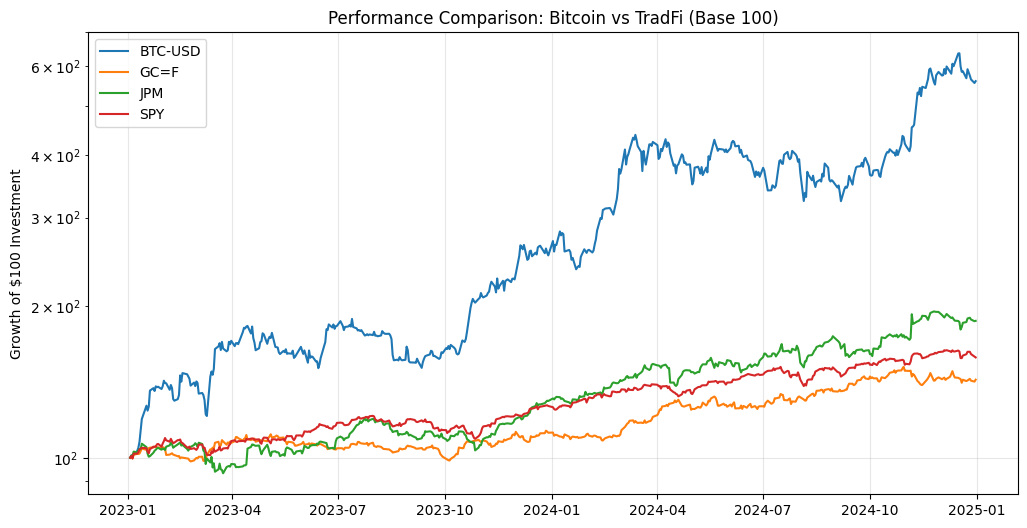

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

# 1. Setup variables
TICKERS = ['SPY', 'GC=F', 'JPM', 'BTC-USD'] 
START_DATE = "2023-01-01" 
END_DATE = "2025-01-01"

# 2. Download data
raw = yf.download(TICKERS, start=START_DATE, end=END_DATE, progress=False)

# Robust data extraction logic
if isinstance(raw.columns, pd.MultiIndex):
    if 'Adj Close' in raw.columns.levels[0]:
        data = raw['Adj Close']
    elif 'Close' in raw.columns.levels[0]:
        data = raw['Close']
    else:
        data = raw.xs(raw.columns.levels[0][0], axis=1, level=0)
else:
    if 'Adj Close' in raw.columns:
        data = raw['Adj Close']
    else:
        data = raw

# --- CRITICAL FIX ---
# Drop rows where ANY ticker is missing data. 
# This auto-adjusts the start date to Sept 2014 (when BTC data starts).
data = data.dropna()

# 3. Normalize data (Rebase to 100)
# This calculates the growth of a $100 investment
normalized_df = (data / data.iloc[0]) * 100

# 4. Plot the graph
plt.figure(figsize=(12, 6))

plt.plot(normalized_df)

# Add labels and style
plt.title(f'Performance Comparison: Bitcoin vs TradFi (Base 100)')
plt.legend(normalized_df.columns) 
plt.ylabel('Growth of $100 Investment')
plt.grid(True, alpha=0.3)

# OPTIONAL: Logarithmic scale
# Bitcoin moves exponentially. A linear scale makes SPY/JPM look flat.
# Uncomment the line below to see relative performance better:
plt.yscale('log') 

plt.show()

In [ ]:
# 1. Setup variables
TICKER = 'SPY'
WINDOW = 200

# 2. Download data
df = yf.download(TICKER,start="1990-01-01", end="2021-01-01")

# 3. Calculate Moving Average
# (Using 'Close' with a capital C, because yfinance requires it)
df['MA'] = df['Close'].rolling(WINDOW).mean()

# 4. Plot the graph
plt.figure(figsize=(10, 5)) # Optional: Makes the chart wider/clearer
plt.plot(df['Close'])
plt.plot(df['MA'])
plt.legend([f'{TICKER} Close Price', f'{WINDOW} Moving Average'])
plt.title(f'{TICKER} Close vs. Moving Average')
plt.show()

In [ ]:
df.columns = df.columns.get_level_values(0)
def add_ma_strategy(df):
    df['Strategy'] = np.where(df['Close'] > df['MA'], 1, -1)
    return df
df = add_ma_strategy(df)
df['asset_cumulative'] = np.cumprod(1 + df['Close'].pct_change()) - 1
df['strategy_cumulative'] = np.cumprod(1 + df['Close'].pct_change() * df['Strategy'].shift()) - 1

In [ ]:
plt.plot(df['asset_cumulative'])
plt.plot(df['strategy_cumulative'])

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TICKER = 'SPY'
WINDOW = 200

def getdata():
    df = yf.download(TICKER, start="1990-01-01", end="2021-01-01")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df['MA'] = df['Close'].rolling(WINDOW).mean()
    return df

def add_ma_strategy(df):
    df['Signal'] = np.where(df['Close'] > df['MA'], 1, -1)
    df['Strategy'] = df['Signal'].shift(1)
    return df

def backtest(df):
    df['asset_cumulative'] = (1 + df['Close'].pct_change()).cumprod() - 1
    df['strategy_cumulative'] = (1 + df['Close'].pct_change() * df['Strategy']).cumprod() - 1
    return df

def main():
    df = getdata()
    df = add_ma_strategy(df)
    df = backtest(df)
    return df

df = main()
print(df.tail())

plt.figure(figsize=(12, 6))
plt.plot(df['asset_cumulative'], label='Asset Cumulative Return')
plt.plot(df['strategy_cumulative'], label='Strategy Cumulative Return')
plt.legend()
plt.title(f'{TICKER} Backtest Results')
plt.show()

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

TICKER = 'SPY'

# --- PARAMETERS ---
EMA_LEN = 200      # Trend Filter
RSI_LEN = 14       # Momentum
ATR_LEN = 14       # Volatility
VOL_LEN = 20       # Volume Average

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_atr(df, period=14):
    high_low = df['High'] - df['Low']
    high_close = np.abs(df['High'] - df['Close'].shift())
    low_close = np.abs(df['Low'] - df['Close'].shift())
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = ranges.max(axis=1)
    return true_range.rolling(window=period).mean()

def getdata():
    # Added High/Low/Volume columns which are needed for ATR and Volume
    df = yf.download(TICKER, start="1990-01-01", end="2026-01-01")
    
    # Fix for multi-level columns in newer yfinance versions
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    # 1. EMA (Exponential Moving Average)
    df['EMA'] = df['Close'].ewm(span=EMA_LEN, adjust=False).mean()
    
    # 2. RSI (Relative Strength Index)
    df['RSI'] = calculate_rsi(df['Close'], RSI_LEN)
    
    # 3. ATR (Average True Range)
    df['ATR'] = calculate_atr(df, ATR_LEN)
    df['ATR_MA'] = df['ATR'].rolling(window=20).mean() # Baseline for volatility
    
    # 4. Volume SMA
    df['Vol_MA'] = df['Volume'].rolling(window=VOL_LEN).mean()
    
    # Drop NaN values created by indicators
    df.dropna(inplace=True)
    return df

def add_strategy(df):
    # --- STRATEGY LOGIC ---
    # Condition 1: Trend is UP (Price > EMA)
    c_trend = df['Close'] > df['EMA']
    
    # Condition 2: Pullback Opportunity (RSI < 55) - Buying the dip
    c_rsi = df['RSI'] < 55
    
    # Condition 3: High Volume (Volume > Average Volume)
    c_vol = df['Volume'] > df['Vol_MA']
    
    # Condition 4: Volatility is expanding (ATR > Average ATR)
    c_atr = df['ATR'] > df['ATR_MA']

    # --- SIGNAL GENERATION ---
    # 1 = Buy, 0 = Hold/Neutral (We use 0 instead of -1 for Long Only strategies usually)
    # But to match your previous code structure: 1 = Long, -1 = Short/Cash
    
    # Generate raw signals
    df['Signal'] = np.where(c_trend & c_rsi & c_vol & c_atr, 1, 0)
    
    # If Signal is 0, check if we should stay in trade or exit
    # Simple exit: If Price < EMA, go to -1 (Sell). Otherwise hold previous position.
    # This vectorization trick propagates the position:
    df['Position'] = np.where(df['Close'] < df['EMA'], 0, np.nan) # Exit condition
    df['Position'] = np.where(df['Signal'] == 1, 1, df['Position']) # Entry condition
    df['Position'] = df['Position'].ffill().fillna(0) # Forward fill holds the position
    
    # Shift by 1 to avoid look-ahead bias (we trade at Open of NEXT day based on TODAY's signal)
    df['Strategy_Shifted'] = df['Position'].shift(1)
    
    return df

def backtest(df):
    # Calculate daily returns
    df['Returns'] = df['Close'].pct_change()
    
    # Asset Cumulative Return (Buy and Hold)
    df['asset_cumulative'] = (1 + df['Returns']).cumprod() - 1
    
    # Strategy Cumulative Return
    # We use Strategy_Shifted to multiply against today's return
    df['strategy_cumulative'] = (1 + df['Returns'] * df['Strategy_Shifted']).cumprod() - 1
    
    return df

def main():
    df = getdata()
    df = add_strategy(df)
    df = backtest(df)
    return df

# Run and Plot
df = main()
print(df[['Close', 'EMA', 'RSI', 'Signal', 'Position']].tail())

plt.figure(figsize=(12, 6))
plt.plot(df['asset_cumulative'], label='Buy & Hold (SPY)', alpha=0.5)
plt.plot(df['strategy_cumulative'], label='ATR-RSI-EMA Strategy', linewidth=2)
plt.legend()
plt.title(f'{TICKER} Backtest: Hybrid Strategy')
plt.grid(True)
plt.show()

--- RESULTS (BTC-USD) ---
Buy & Hold:
  Final Value:    $64,075
  Total Return:   540.75%
  Max Drawdown:   -81.53%
------------------------------
AMD Strategy:
  Final Value:    $138,073
  Total Return:   1,280.73%
  Max Drawdown:   -45.47%


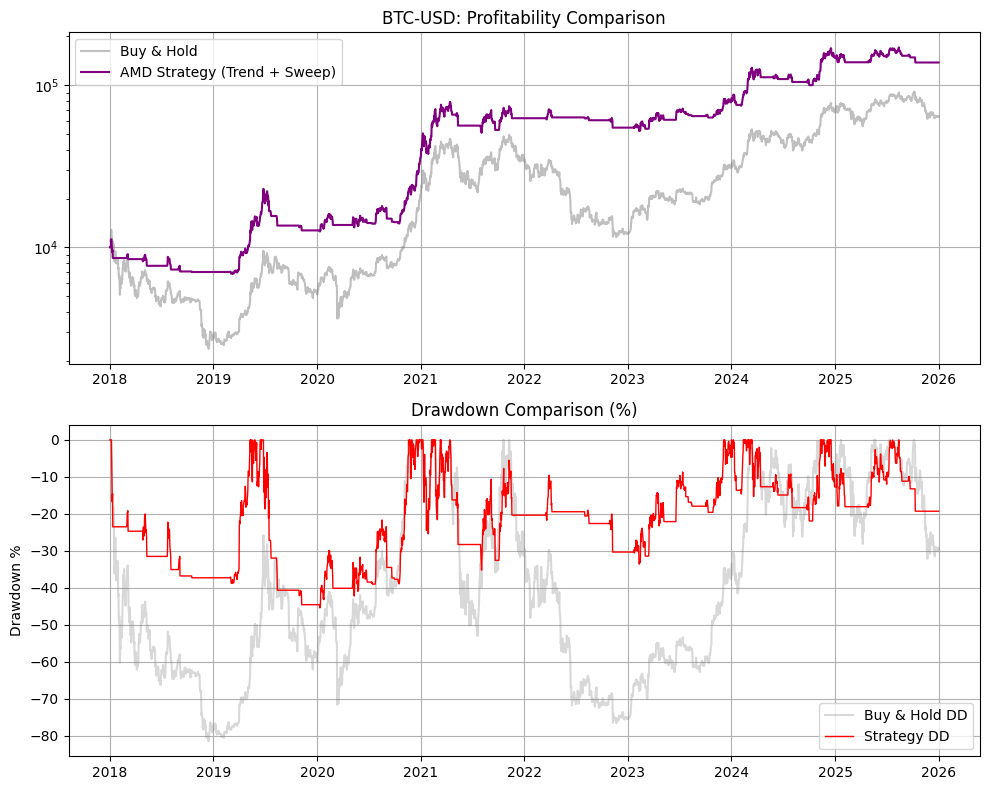

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup variables
TICKER = 'BTC-USD'
START_DATE = "2018-01-01"
END_DATE = "2026-01-01"
INITIAL_CAPITAL = 10000
EMA_PERIOD = 50 

# 2. Download data
df = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# 3. Calculate Indicators
df['EMA'] = df['Close'].ewm(span=EMA_PERIOD, adjust=False).mean()

# Liquidity Levels (Previous Day)
df['Prev_High'] = df['High'].shift(1)
df['Prev_Low'] = df['Low'].shift(1)

# 4. Strategy Logic
positions = []
in_position = False

for index, row in df.iterrows():
    price = row['Close']
    low = row['Low']
    prev_low = row['Prev_Low']
    ema = row['EMA']
    
    # EXIT RULE: Trend Break (Distribution Complete)
    if in_position:
        if price < ema:
            in_position = False
            positions.append(0)
        else:
            positions.append(1) # Hold
            
    # ENTRY RULE: Trend + Manipulation (Accumulation)
    else:
        # Context: Bull Trend (Price > EMA 50)
        if price > ema:
            # Trigger: Liquidity Grab (Manipulation)
            # Price sweeps below previous low but closes above it (SFP)
            liquidity_grab = (low < prev_low) and (price > prev_low)
            
            if liquidity_grab:
                in_position = True
                positions.append(1)
            else:
                positions.append(0) # Wait for the grab
        else:
            positions.append(0) # Bear market

df['Position'] = positions

# 5. Returns & Drawdowns

# --- STRATEGY ---
df['Strat_Return'] = df['Position'].shift(1) * df['Close'].pct_change()
df['Strat_Curve'] = (1 + df['Strat_Return'].fillna(0)).cumprod() * INITIAL_CAPITAL
df['Strat_Peak'] = df['Strat_Curve'].cummax()
df['Strat_Drawdown'] = (df['Strat_Curve'] - df['Strat_Peak']) / df['Strat_Peak']
strat_dd = df['Strat_Drawdown'].min() * 100
final_strat = df['Strat_Curve'].iloc[-1]
# Total Return %
strat_pct_ret = ((final_strat - INITIAL_CAPITAL) / INITIAL_CAPITAL) * 100

# --- BUY & HOLD (BENCHMARK) ---
df['BH_Return'] = df['Close'].pct_change()
df['BH_Curve'] = (1 + df['BH_Return']).cumprod() * INITIAL_CAPITAL
df['BH_Peak'] = df['BH_Curve'].cummax()
df['BH_Drawdown'] = (df['BH_Curve'] - df['BH_Peak']) / df['BH_Peak']
bh_dd = df['BH_Drawdown'].min() * 100
final_bh = df['BH_Curve'].iloc[-1]
# Total Return %
bh_pct_ret = ((final_bh - INITIAL_CAPITAL) / INITIAL_CAPITAL) * 100

print(f"--- RESULTS ({TICKER}) ---")
print(f"Buy & Hold:")
print(f"  Final Value:    ${final_bh:,.0f}")
print(f"  Total Return:   {bh_pct_ret:,.2f}%")
print(f"  Max Drawdown:   {bh_dd:.2f}%")
print("-" * 30)
print(f"AMD Strategy:")
print(f"  Final Value:    ${final_strat:,.0f}")
print(f"  Total Return:   {strat_pct_ret:,.2f}%")
print(f"  Max Drawdown:   {strat_dd:.2f}%")

plt.figure(figsize=(10, 8))

# Subplot 1: Value
plt.subplot(2, 1, 1)
plt.plot(df['BH_Curve'], label='Buy & Hold', color='gray', alpha=0.5)
plt.plot(df['Strat_Curve'], label='AMD Strategy (Trend + Sweep)', color='purple')
plt.yscale('log')
plt.title(f'{TICKER}: Profitability Comparison')
plt.legend()
plt.grid(True)

# Subplot 2: Drawdowns
plt.subplot(2, 1, 2)
plt.plot(df.index, df['BH_Drawdown']*100, label='Buy & Hold DD', color='gray', alpha=0.3)
plt.plot(df.index, df['Strat_Drawdown']*100, label='Strategy DD', color='red', linewidth=1)
plt.title('Drawdown Comparison (%)')
plt.ylabel('Drawdown %')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Resolving data sources...
  Timeframe : 5Min  |  window: 2022-01-01 → 2024-12-31
  Credentials loaded from: c:\Users\Lenovo\Desktop\VGBN\.vscode\CODEPTIT\personal_finance_draft\.env
  [Alpaca]  QQQ 5Min bars loaded.
  QQQ 5Min : 68311 bars (2022-01-03 → 2024-12-31)
  QQQ daily   : 752 bars | VIX daily: 752 bars

Building indicators...
  VIX-blocked days : 58
  Trading days     : 695

Running Model A (Institutional)...

═══════════════════════════════════════════════════════
  Model A (Institutional)
═══════════════════════════════════════════════════════
  total_trades          : 809
  wins                  : 344
  losses                : 465
  win_rate              : 0.4252
  total_pnl             : -21566.6888
  avg_pnl               : -26.6585
  avg_win               : 80.4047
  avg_loss              : -105.8622
  profit_factor         : 0.5619
  total_return          : -0.8627
  final_equity          : 3433.3112
  max_drawdown          : -0.8701
  total_fees            : 0.0000
  s

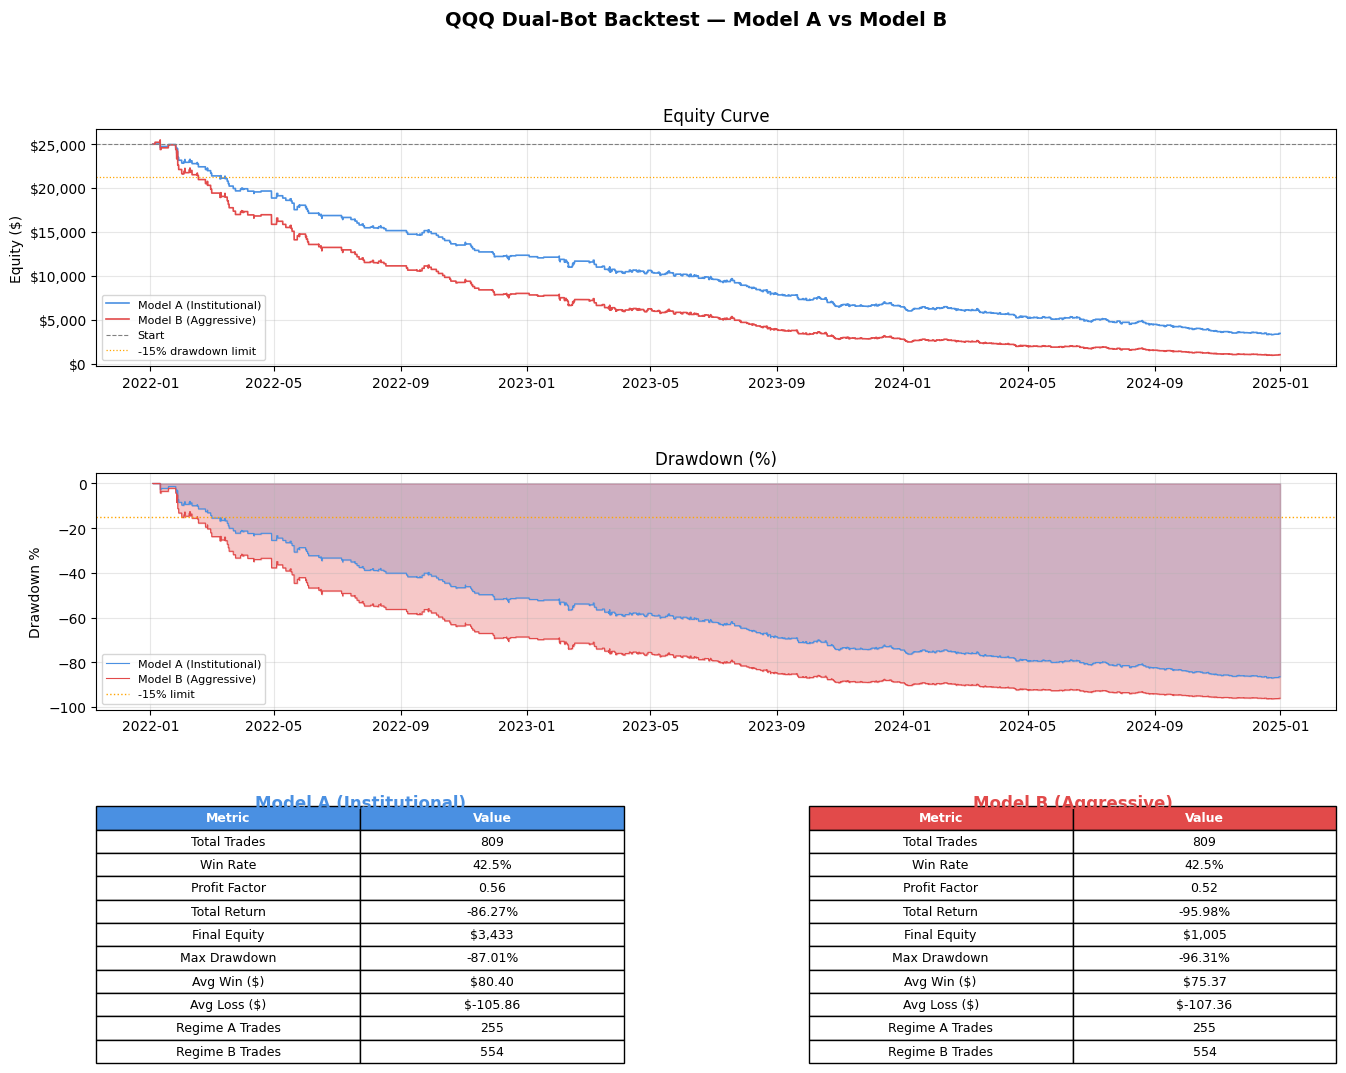

Chart saved → qqq_dual_bot_results.png


In [7]:
"""
QQQ Dual-Bot Backtest
=====================
Logic Core  : VIX macro block | Daily VWAP ±2.5 SD | Yesterday HVN | Daily EMA-200
Regime A    : Sniper  — mean-reversion at ±2.5 SD (HVN brick-wall constraint)
Regime B    : Workhorse — trend pullback to VWAP midline (price > EMA-200 required)
Model A     : Institutional — 1.25% risk / 2.5× leverage / $25 000 cap
Model B     : Aggressive   — 2.00% risk / 4.0× leverage / $25 000 cap
Time Stop   : All positions closed at 15:55 ET (no overnight)

Run inside the notebook:  %run qqq_dual_bot.py
Or standalone:            python qqq_dual_bot.py
"""

# ── 0. IMPORTS ────────────────────────────────────────────────────────────────
import warnings, sys, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import yfinance as yf
import requests
from dataclasses import dataclass, field
from typing import Optional, List, Dict
from datetime import time as dt_time

# ── 1. CONFIG ────────────────────────────────────────────────────────────────
TICKER       = "QQQ"
VIX_TICKER   = "^VIX"
INITIAL_EQ   = 25_000.0
EQUITY_CAP   = 25_000.0

# Risk modules
MODEL_A = dict(name="Model A (Institutional)", risk=0.0125, leverage=2.5)
MODEL_B = dict(name="Model B (Aggressive)",   risk=0.0200, leverage=4.0)
MAX_LEVERAGE = 4.0    # hard ceiling: position value ≤ trading_equity × MAX_LEVERAGE

# Signal params
SL_PCT       = 0.005   # 0.5% stop loss (both regimes)
TP_REGIME_B  = 0.0075  # 0.75% TP for Workhorse
SD_MULT      = 2.5     # VWAP band multiplier
HVN_BINS     = 10      # bins for HVN calculation
BRICK_WALL   = 0.005   # 0.5% proximity for HVN brick-wall
VWAP_WARMUP  = 3       # bars to skip at session open (collapsed SD false-signal guard)
VIX_SPIKE_TH = 0.10    # 10% VIX spike → disable day
EMA_PERIOD   = 200     # Daily EMA period

# Execution costs
SLIPPAGE     = 0.0005  # 0.05% per fill (market impact + half-spread)
COMMISSION   = 0.0     # Alpaca US equities = $0 commission

MARKET_OPEN  = dt_time(9, 30)
TIME_STOP    = dt_time(15, 55)

# ── Date & timeframe tuning ───────────────────────────────────────────────────
# Set START_DATE / END_DATE to strings like "2023-01-01" to pin the window.
# Leave as None to use the rolling defaults (DATA_DAYS back from today).
START_DATE   = "2022-01-01"   # full bear + recovery + bull cycle
END_DATE     = "2024-12-31"
DATA_DAYS    = 365            # ignored when START_DATE is set
TIMEFRAME    = "5Min"      # Alpaca: "1Min" | "5Min" | "15Min" | "1Hour" | "1Day"
YF_INTERVAL  = "5m"        # yfinance fallback: "1m" | "5m" | "15m" | "1h"


# ── 2. DATA ───────────────────────────────────────────────────────────────────
def _parse_env_file(path: str):
    """Return (key, secret) from a .env file, or (None, None) if not found."""
    key, secret = None, None
    try:
        with open(path, "r") as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith("#") or "=" not in line:
                    continue
                k, v = line.split("=", 1)
                k = k.strip()
                v = v.strip().strip('"').strip("'")
                if k == "ALPACA_API_KEY":
                    key = v
                elif k == "ALPACA_API_SECRET":
                    secret = v
    except OSError:
        pass
    return key, secret


def load_alpaca_credentials():
    """
    Load Alpaca API keys.
    Priority: environment variables → walk upward from the script's own directory
    (not CWD) checking for .env and personal_finance_draft/.env at each level.
    This survives being run from any working directory.
    """
    key = os.environ.get("ALPACA_API_KEY")
    secret = os.environ.get("ALPACA_API_SECRET")
    if key and secret:
        return key, secret

    # Start from the directory that contains *this* script, not the shell CWD.
    script_dir = os.path.dirname(os.path.abspath(
        globals().get("__file__", os.getcwd())
    ))
    current = script_dir
    for _ in range(5):  # walk at most 5 levels up
        for candidate in (
            os.path.join(current, ".env"),
            os.path.join(current, "personal_finance_draft", ".env"),
        ):
            if os.path.exists(candidate):
                key, secret = _parse_env_file(candidate)
                if key and secret:
                    print(f"  Credentials loaded from: {candidate}")
                    return key, secret
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent

    return None, None


def download_alpaca_bars(key, secret, symbol="QQQ",
                         start_date=None, end_date=None,
                         days=365, timeframe="5Min"):
    """Fetch bars from Alpaca v2 with pagination. Respects START_DATE/END_DATE if set."""
    from datetime import datetime, timedelta, timezone
    end_dt   = datetime.strptime(end_date,   "%Y-%m-%d").replace(tzinfo=timezone.utc) if end_date   else datetime.now(timezone.utc)
    start_dt = datetime.strptime(start_date, "%Y-%m-%d").replace(tzinfo=timezone.utc) if start_date else end_dt - timedelta(days=days)

    url     = "https://data.alpaca.markets/v2/stocks/bars"
    headers = {"APCA-API-KEY-ID": key, "APCA-API-SECRET-KEY": secret}
    params  = {
        "symbols":    symbol,
        "timeframe":  timeframe,
        "start":      start_dt.strftime("%Y-%m-%dT00:00:00Z"),
        "end":        end_dt.strftime("%Y-%m-%dT23:59:59Z"),
        "limit":      10000,
        "feed":       "iex",
        "adjustment": "all",
    }
    all_bars, page_token = [], None
    while True:
        if page_token:
            params["page_token"] = page_token
        res = requests.get(url, headers=headers, params=params)
        if res.status_code != 200:
            raise Exception(f"Alpaca Error {res.status_code}: {res.text}")
        data = res.json()
        all_bars.extend(data.get("bars", {}).get(symbol, []))
        page_token = data.get("next_page_token")
        if not page_token:
            break
    if not all_bars:
        raise Exception("No bars returned from Alpaca")
    df = pd.DataFrame(all_bars).rename(columns={
        "t": "Timestamp", "o": "Open", "h": "High", "l": "Low", "c": "Close", "v": "Volume"
    })
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    return df.set_index("Timestamp")


def download_data():
    print("Resolving data sources...")
    print(f"  Timeframe : {TIMEFRAME}  |  window: {START_DATE or f'-{DATA_DAYS}d'} → {END_DATE or 'today'}")
    key, secret = load_alpaca_credentials()

    if key and secret:
        try:
            qqq5 = download_alpaca_bars(
                key, secret, TICKER,
                start_date=START_DATE, end_date=END_DATE,
                days=DATA_DAYS, timeframe=TIMEFRAME,
            )
            print(f"  [Alpaca]  QQQ {TIMEFRAME} bars loaded.")
        except Exception as e:
            print(f"  Alpaca download failed: {e}. Falling back to yfinance...")
            print("  ⚠ WARNING: yfinance caps intraday history at ~60 days. "
                  "Metrics on this window are NOT comparable to an Alpaca run.")
            qqq5 = yf.download(TICKER, period="60d", interval=YF_INTERVAL,
                               auto_adjust=True, progress=False)
    else:
        print("  No Alpaca credentials — using yfinance (60-day cap).")
        print("  ⚠ WARNING: 60-day window produces statistically thin metrics. "
              "Set Alpaca credentials for a full-year backtest.")
        qqq5 = yf.download(TICKER, period="60d", interval=YF_INTERVAL,
                           auto_adjust=True, progress=False)

    # Daily reference data (VIX spike map + EMA-200)
    daily_start = START_DATE or None
    daily_end   = END_DATE   or None
    qqq1 = yf.download(TICKER,     start=daily_start, end=daily_end,
                       period=(None if daily_start else "2y"),
                       interval="1d", auto_adjust=True, progress=False)
    vix1 = yf.download(VIX_TICKER, start=daily_start, end=daily_end,
                       period=(None if daily_start else "2y"),
                       interval="1d", auto_adjust=True, progress=False)

    for df in (qqq5, qqq1, vix1):
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

    if qqq5.index.tz is None:
        qqq5.index = qqq5.index.tz_localize("UTC").tz_convert("America/New_York")
    else:
        qqq5.index = qqq5.index.tz_convert("America/New_York")

    print(f"  QQQ {TIMEFRAME} : {len(qqq5)} bars ({qqq5.index[0].date()} → {qqq5.index[-1].date()})")
    print(f"  QQQ daily   : {len(qqq1)} bars | VIX daily: {len(vix1)} bars")
    return qqq5, qqq1, vix1


# ── 3. LOGIC CORE ─────────────────────────────────────────────────────────────
def compute_vwap_bands(df5: pd.DataFrame) -> pd.DataFrame:
    """Intraday VWAP + ±2.5 SD (volume-weighted), resets each session."""
    df = df5.copy()
    df["_d"]  = df.index.date
    df["tp"]  = (df["High"] + df["Low"] + df["Close"]) / 3
    df["tpv"] = df["tp"] * df["Volume"]
    df["tp2v"]= df["tp"]**2 * df["Volume"]
    g = df.groupby("_d")
    cv   = g["Volume"].cumsum()
    ctpv = g["tpv"].cumsum()
    ctp2v= g["tp2v"].cumsum()
    df["vwap"]    = ctpv / cv
    var           = (ctp2v / cv) - df["vwap"]**2
    df["vwap_sd"] = np.sqrt(var.clip(lower=0))
    df["vwap_hi"] = df["vwap"] + SD_MULT * df["vwap_sd"]
    df["vwap_lo"] = df["vwap"] - SD_MULT * df["vwap_sd"]
    return df.drop(columns=["tp","tpv","tp2v"])


def compute_ema200(qqq1: pd.DataFrame) -> Dict:
    """Daily EMA-200 → {date: value}."""
    ema = qqq1["Close"].ewm(span=EMA_PERIOD, adjust=False).mean()
    return {d.date(): float(v) for d, v in zip(qqq1.index, ema)}


def compute_hvn(prev_day: Optional[pd.DataFrame]) -> Optional[float]:
    """Highest-volume price bin midpoint from previous day's 5-min bars."""
    if prev_day is None or len(prev_day) == 0:
        return None
    closes = prev_day["Close"].values.astype(float)
    vols   = prev_day["Volume"].values.astype(float)
    lo, hi = closes.min(), closes.max()
    if lo == hi:
        return float(lo)
    edges    = np.linspace(lo, hi, HVN_BINS + 1)
    bin_idx  = np.clip(np.digitize(closes, edges) - 1, 0, HVN_BINS - 1)
    bin_vol  = np.zeros(HVN_BINS)
    for i, v in zip(bin_idx, vols):
        bin_vol[i] += v
    best = int(np.argmax(bin_vol))
    return float((edges[best] + edges[best + 1]) / 2)


def build_vix_spike_map(vix1: pd.DataFrame) -> Dict:
    """True if yesterday's VIX close spiked >10% vs the day before → disable today."""
    closes = vix1["Close"].values.astype(float)
    dates  = [d.date() for d in vix1.index]
    out = {}
    for i in range(2, len(dates)):
        p0, p1 = closes[i-2], closes[i-1]
        out[dates[i]] = (p1 - p0) / p0 > VIX_SPIKE_TH if p0 > 0 else False
    return out


def attach_hvn_column(df5: pd.DataFrame) -> pd.DataFrame:
    """Add 'hvn' column: previous trading day's HVN, constant for each day."""
    df = df5.copy()
    df["_d"] = df.index.date
    days   = sorted(df["_d"].unique())
    day_groups = {d: df[df["_d"] == d] for d in days}
    hvn_map = {}
    for i, d in enumerate(days):
        prev = day_groups[days[i-1]] if i > 0 else None
        hvn_map[d] = compute_hvn(prev)
    df["hvn"] = df["_d"].map(hvn_map)
    return df


# ── 4. POSITION / RISK ────────────────────────────────────────────────────────
@dataclass
class Position:
    regime:      str            # 'A' or 'B'
    direction:   str            # 'long' | 'short'
    entry_price: float
    sl_price:    float
    tp_price:    Optional[float]  # None → use VWAP for Regime A
    shares:      float
    entry_ts:    object


def size_shares(equity: float, risk_pct: float, entry_price: float):
    """
    Capacity-compounding position sizer per spec pseudocode.
    - trading_equity: capped at EQUITY_CAP; excess swept to vault.
    - risk_usd = trading_equity * risk_pct
    - position_value = risk_usd / SL_PCT   (implicit leverage = risk/SL)
    - position_value is hard-capped at trading_equity * MAX_LEVERAGE to prevent
      notional exceeding available margin when equity has shrunk significantly.
    - qty = int(position_value / entry_price)  [integer shares only]
    Returns (qty, cash_reserve).
    """
    trading_equity = min(equity, EQUITY_CAP)
    cash_reserve   = max(0.0, equity - EQUITY_CAP)
    risk_usd       = trading_equity * risk_pct
    position_value = risk_usd / SL_PCT
    position_value = min(position_value, trading_equity * MAX_LEVERAGE)  # leverage cap
    qty            = int(position_value / entry_price)   # integer shares, no fractional
    return qty, cash_reserve


def is_near_hvn(price: float, hvn) -> bool:
    # pandas stores None as NaN in float columns, so check both.
    if hvn is None or hvn == 0:
        return False
    try:
        if np.isnan(hvn):
            return False
    except (TypeError, ValueError):
        return False
    return abs(price - hvn) / hvn <= BRICK_WALL


def calc_pnl(pos: Position, exit_price: float) -> float:
    mult = 1 if pos.direction == "long" else -1
    return mult * (exit_price - pos.entry_price) * pos.shares


# ── 5. BACKTEST LOOP ──────────────────────────────────────────────────────────
def apply_slippage(price: float, direction: str, side: str) -> float:
    """Apply half-spread slippage to a fill price.
    direction: 'long' | 'short'   side: 'entry' | 'exit'
    Long  entry  → buy  → pays more  (+slip)
    Long  exit   → sell → receives less (-slip)
    Short entry  → sell → receives less (-slip)
    Short exit   → buy  → pays more  (+slip)
    """
    if direction == "long":
        return price * (1 + SLIPPAGE) if side == "entry" else price * (1 - SLIPPAGE)
    else:
        return price * (1 - SLIPPAGE) if side == "entry" else price * (1 + SLIPPAGE)


def run_backtest(df5_full: pd.DataFrame, ema200: Dict, vix_map: Dict,
                 risk: float, model_name: str) -> Dict:
    equity      = INITIAL_EQ
    vault_bal   = 0.0         # Bug #1: accumulate equity swept above EQUITY_CAP
    eq_curve    = []
    trades      = []
    total_fees  = 0.0
    pos: Optional[Position] = None

    days = sorted(df5_full["_d"].unique())

    for day in days:
        day_df = df5_full[df5_full["_d"] == day]

        # VIX macro block
        if vix_map.get(day, False):
            eq_curve.append((day_df.index[-1], equity))
            continue

        ema_val   = ema200.get(day, None)
        pos       = None   # fresh position tracker per day (one position at a time)
        bar_count = 0      # count of bars at/after market open (VWAP warmup)

        rows_list = list(day_df.iterrows())  # materialise once; avoids O(n²) re-scan
        for bar_i, (ts, row) in enumerate(rows_list):
            bar_time = ts.time()
            if bar_time < MARKET_OPEN:
                continue

            bar_count += 1   # first bar at/after open = bar 1

            close = float(row["Close"])
            high  = float(row["High"])
            low   = float(row["Low"])
            vwap  = float(row.get("vwap", np.nan))
            vhi   = float(row.get("vwap_hi", np.nan))
            vlo   = float(row.get("vwap_lo", np.nan))
            hvn   = row.get("hvn", None)
            if not np.isfinite(vwap):
                continue

            # ── Time Stop ─────────────────────────────────────────────────────
            if bar_time >= TIME_STOP:
                if pos is not None:
                    raw_exit = close
                    fill_exit = apply_slippage(raw_exit, pos.direction, "exit")
                    fee = COMMISSION * pos.shares
                    pnl = calc_pnl(pos, fill_exit) - fee
                    equity += pnl
                    total_fees += fee
                    trades.append(dict(date=day, regime=pos.regime,
                                       direction=pos.direction,
                                       entry=pos.entry_price, exit=fill_exit,
                                       shares=pos.shares, pnl=pnl, fees=fee,
                                       exit_reason="time_stop"))
                    pos = None
                eq_curve.append((ts, equity))
                break

            # ── Manage open position ──────────────────────────────────────────
            if pos is not None:
                raw_exit = None
                reason   = None
                if pos.direction == "long":
                    if low <= pos.sl_price:
                        raw_exit, reason = pos.sl_price, "stop_loss"
                    elif pos.tp_price and high >= pos.tp_price:
                        raw_exit, reason = pos.tp_price, "take_profit"
                    elif pos.regime == "A" and np.isfinite(vwap) and high >= vwap:
                        raw_exit, reason = vwap, "vwap_tp"
                else:  # short
                    if high >= pos.sl_price:
                        raw_exit, reason = pos.sl_price, "stop_loss"
                    elif pos.tp_price and low <= pos.tp_price:
                        raw_exit, reason = pos.tp_price, "take_profit"
                    elif pos.regime == "A" and np.isfinite(vwap) and low <= vwap:
                        raw_exit, reason = vwap, "vwap_tp"

                if raw_exit is not None:
                    # Both legs pay slippage — round-trip = 2× SLIPPAGE per trade.
                    fill_exit = apply_slippage(raw_exit, pos.direction, "exit")
                    fee  = COMMISSION * pos.shares
                    pnl  = calc_pnl(pos, fill_exit) - fee
                    equity += pnl
                    total_fees += fee
                    trades.append(dict(date=day, regime=pos.regime,
                                       direction=pos.direction,
                                       entry=pos.entry_price, exit=fill_exit,
                                       raw_close=pos.entry_price / (1 + SLIPPAGE
                                           if pos.direction == "long" else 1 - SLIPPAGE),
                                       shares=pos.shares, pnl=pnl, fees=fee,
                                       exit_reason=reason))
                    pos = None
                eq_curve.append((ts, equity))
                continue

            # ── Signal Engine — Regime A: Sniper ─────────────────────────────
            # Spec: entry on CLOSE of triggering candle (not intrabar touch).
            # HVN is a BRICK WALL: if close is near HVN, institutions defend that
            # level → mean-reversion is unlikely → block the trade.
            # Minimum VWAP_WARMUP bars must have elapsed so SD is non-trivial.
            if pos is None and bar_count > VWAP_WARMUP and np.isfinite(vhi) and np.isfinite(vlo):
                if close <= vlo and not is_near_hvn(close, hvn):
                    qty, swept = size_shares(equity, risk, close)
                    vault_bal += swept   # accumulate swept capital
                    if qty > 0:
                        fill = apply_slippage(close, "long", "entry")
                        fee  = COMMISSION * qty
                        equity -= fee
                        total_fees += fee
                        sl = fill * (1 - SL_PCT)
                        pos = Position("A", "long", fill, sl, None, qty, ts)
                elif close >= vhi and not is_near_hvn(close, hvn):
                    qty, swept = size_shares(equity, risk, close)
                    vault_bal += swept
                    if qty > 0:
                        fill = apply_slippage(close, "short", "entry")
                        fee  = COMMISSION * qty
                        equity -= fee
                        total_fees += fee
                        sl = fill * (1 + SL_PCT)
                        pos = Position("A", "short", fill, sl, None, qty, ts)

            # ── Signal Engine — Regime B: Workhorse ──────────────────────────
            # Spec: prev candle LOW pierces below VWAP, current candle CLOSE back above VWAP.
            # NOTE: Long-only. When close < EMA-200 (bear trend) no trades fire.
            #       This is intentional but creates a bull-market bias in the metrics.
            if pos is None and bar_count > VWAP_WARMUP and ema_val is not None and close > ema_val and bar_i > 0:
                prev_ts, prev_row = rows_list[bar_i - 1]
                if prev_ts.time() >= MARKET_OPEN:
                    prev_low  = float(prev_row["Low"])
                    prev_vwap = float(prev_row.get("vwap", np.nan))
                    if (np.isfinite(prev_vwap)
                            and prev_low < prev_vwap
                            and close > vwap):
                        qty, swept = size_shares(equity, risk, close)
                        vault_bal += swept
                        if qty > 0:
                            fill = apply_slippage(close, "long", "entry")
                            fee  = COMMISSION * qty
                            equity -= fee
                            total_fees += fee
                            sl = fill * (1 - SL_PCT)
                            tp = fill * (1 + TP_REGIME_B)
                            pos = Position("B", "long", fill, sl, tp, qty, ts)

            eq_curve.append((ts, equity))

        # End of day: close any open position (shouldn’t happen with time-stop)
        if pos is not None and len(day_df) > 0:
            raw_exit = float(day_df.iloc[-1]["Close"])
            fill_exit = apply_slippage(raw_exit, pos.direction, "exit")
            fee = COMMISSION * pos.shares
            pnl = calc_pnl(pos, fill_exit) - fee
            equity += pnl
            total_fees += fee
            trades.append(dict(date=day, regime=pos.regime,
                               direction=pos.direction,
                               entry=pos.entry_price, exit=fill_exit,
                               shares=pos.shares, pnl=pnl, fees=fee,
                               exit_reason="eod_close"))
            pos = None

    return dict(name=model_name, equity_curve=eq_curve, trades=trades,
                final_equity=equity, vault_balance=vault_bal, total_fees=total_fees)



# ── 6. METRICS ────────────────────────────────────────────────────────────────
def compute_metrics(result: Dict) -> Dict:
    trades = result["trades"]
    if not trades:
        return {}
    pnls     = [t["pnl"] for t in trades]
    wins     = [p for p in pnls if p > 0]
    losses   = [p for p in pnls if p <= 0]
    eq_vals  = [e for _, e in result["equity_curve"]]
    peak     = pd.Series(eq_vals).cummax()
    dd       = (pd.Series(eq_vals) - peak) / peak
    total_ret = (result["final_equity"] - INITIAL_EQ) / INITIAL_EQ
    total_fees = result.get("total_fees", 0.0)
    slip_drag = sum(
        abs(t["shares"]) * t.get("raw_close", t["entry"]) * SLIPPAGE * 2
        for t in trades
    )
    return dict(
        total_trades    = len(trades),
        wins            = len(wins),
        losses          = len(losses),
        win_rate        = len(wins) / len(trades) if trades else 0,
        total_pnl       = sum(pnls),
        avg_pnl         = np.mean(pnls) if pnls else 0,
        avg_win         = np.mean(wins) if wins else 0,
        avg_loss        = np.mean(losses) if losses else 0,
        profit_factor   = sum(wins) / abs(sum(losses)) if losses and sum(losses) != 0 else np.inf,
        total_return    = total_ret,
        final_equity    = result["final_equity"],
        max_drawdown    = float(dd.min()),
        total_fees      = total_fees,
        slip_drag_usd   = slip_drag,
        regime_A_trades = sum(1 for t in trades if t["regime"] == "A"),
        regime_B_trades = sum(1 for t in trades if t["regime"] == "B"),
    )


# ── 7. PLOTTING ───────────────────────────────────────────────────────────────
def plot_results(res_a: Dict, res_b: Dict, metrics_a: Dict, metrics_b: Dict):
    fig = plt.figure(figsize=(16, 12))
    fig.suptitle("QQQ Dual-Bot Backtest — Model A vs Model B", fontsize=14, fontweight="bold")
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

    # ── Equity curves ────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])
    for res, color, lbl in [(res_a, "#4A90E2", res_a["name"]),
                             (res_b, "#E24A4A", res_b["name"])]:
        ts  = [t for t, _ in res["equity_curve"]]
        eq  = [e for _, e in res["equity_curve"]]
        ax1.plot(ts, eq, color=color, linewidth=1.2, label=lbl)
    ax1.axhline(INITIAL_EQ, color="gray", linestyle="--", linewidth=0.8, label="Start")
    ax1.axhline(INITIAL_EQ * 0.85, color="orange", linestyle=":", linewidth=0.9, label="-15% drawdown limit")
    ax1.set_title("Equity Curve")
    ax1.set_ylabel("Equity ($)")
    ax1.legend(fontsize=8)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
    ax1.grid(alpha=0.3)

    # ── Drawdown ─────────────────────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, :])
    for res, color in [(res_a, "#4A90E2"), (res_b, "#E24A4A")]:
        eq   = pd.Series([e for _, e in res["equity_curve"]])
        dd   = (eq - eq.cummax()) / eq.cummax() * 100
        ts   = [t for t, _ in res["equity_curve"]]
        ax2.fill_between(ts, dd, 0, alpha=0.3, color=color)
        ax2.plot(ts, dd, color=color, linewidth=0.8, label=res["name"])
    ax2.axhline(-15, color="orange", linestyle=":", linewidth=1, label="-15% limit")
    ax2.set_title("Drawdown (%)")
    ax2.set_ylabel("Drawdown %")
    ax2.legend(fontsize=8)
    ax2.grid(alpha=0.3)

    # ── Metrics table ────────────────────────────────────────────────────────
    def metrics_panel(ax, m, title, color):
        ax.axis("off")
        rows = [
            ["Metric", "Value"],
            ["Total Trades",    str(m.get("total_trades", 0))],
            ["Win Rate",        f"{m.get('win_rate', 0)*100:.1f}%"],
            ["Profit Factor",   f"{m.get('profit_factor', 0):.2f}"],
            ["Total Return",    f"{m.get('total_return', 0)*100:.2f}%"],
            ["Final Equity",    f"${m.get('final_equity', 0):,.0f}"],
            ["Max Drawdown",    f"{m.get('max_drawdown', 0)*100:.2f}%"],
            ["Avg Win ($)",     f"${m.get('avg_win', 0):,.2f}"],
            ["Avg Loss ($)",    f"${m.get('avg_loss', 0):,.2f}"],
            ["Regime A Trades", str(m.get("regime_A_trades", 0))],
            ["Regime B Trades", str(m.get("regime_B_trades", 0))],
        ]
        tbl = ax.table(cellText=rows[1:], colLabels=rows[0],
                       loc="center", cellLoc="center")
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9)
        tbl.scale(1, 1.4)
        tbl[(0, 0)].set_facecolor(color)
        tbl[(0, 1)].set_facecolor(color)
        tbl[(0, 0)].set_text_props(color="white", fontweight="bold")
        tbl[(0, 1)].set_text_props(color="white", fontweight="bold")
        ax.set_title(title, fontweight="bold", pad=6, color=color)

    metrics_panel(fig.add_subplot(gs[2, 0]), metrics_a, res_a["name"], "#4A90E2")
    metrics_panel(fig.add_subplot(gs[2, 1]), metrics_b, res_b["name"], "#E24A4A")

    plt.savefig("qqq_dual_bot_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Chart saved → qqq_dual_bot_results.png")


# ── 8. TRADE LOG ──────────────────────────────────────────────────────────────
def print_summary(res: Dict, metrics: Dict):
    print(f"\n{'═'*55}")
    print(f"  {res['name']}")
    print(f"{'═'*55}")
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"  {k:<22}: {v:.4f}")
        else:
            print(f"  {k:<22}: {v}")


# ── 9. MAIN ───────────────────────────────────────────────────────────────────
def main():
    # Data
    qqq5, qqq1, vix1 = download_data()

    # Indicators
    print("\nBuilding indicators...")
    df = compute_vwap_bands(qqq5)
    df = attach_hvn_column(df)
    ema200  = compute_ema200(qqq1)
    vix_map = build_vix_spike_map(vix1)

    days_blocked = sum(1 for d in df["_d"].unique() if vix_map.get(d, False))
    print(f"  VIX-blocked days : {days_blocked}")
    print(f"  Trading days     : {len(df['_d'].unique()) - days_blocked}")

    # Backtest — Model A
    print("\nRunning Model A (Institutional)...")
    res_a = run_backtest(df, ema200, vix_map, MODEL_A["risk"], MODEL_A["name"])
    met_a = compute_metrics(res_a)
    print_summary(res_a, met_a)

    # Backtest — Model B
    print("\nRunning Model B (Aggressive)...")
    res_b = run_backtest(df, ema200, vix_map, MODEL_B["risk"], MODEL_B["name"])
    met_b = compute_metrics(res_b)
    print_summary(res_b, met_b)

    # Trade log comparison
    tdf_a = pd.DataFrame(res_a["trades"])
    tdf_b = pd.DataFrame(res_b["trades"])
    if len(tdf_a):
        print(f"\nModel A — last 5 trades:\n{tdf_a[['date','regime','direction','entry','exit','shares','pnl','fees','exit_reason']].tail().to_string(index=False)}")
    if len(tdf_b):
        print(f"\nModel B — last 5 trades:\n{tdf_b[['date','regime','direction','entry','exit','shares','pnl','fees','exit_reason']].tail().to_string(index=False)}")

    # Plot
    plot_results(res_a, res_b, met_a, met_b)

    return res_a, res_b, met_a, met_b


if __name__ == "__main__":
    res_a, res_b, met_a, met_b = main()
